In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys, os
# Robust src path — works whether run manually or via papermill
_src_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'src'))
if _src_path not in sys.path:
    sys.path.insert(0, _src_path)
from config import *

df = pd.read_csv(f'{OUT_PATH}01_clean_sales.csv')
df['sale_date'] = pd.to_datetime(df['sale_date'])

print(f"Loaded: {len(df):,} rows")
print(f"Columns: {df.columns.tolist()}")

Loaded: 43,905 rows
Columns: ['year', 'month', 'Portal', 'Brand Code Text', 'Brand(Masked)', 'Division', 'Material Number', 'Masked SKU', 'Range', 'Masked Range', 'Size', 'Final Channel', 'Final Sub Channel', 'qty', 'net_sales', 'sale_date']


In [2]:
print(df.columns.tolist())

['year', 'month', 'Portal', 'Brand Code Text', 'Brand(Masked)', 'Division', 'Material Number', 'Masked SKU', 'Range', 'Masked Range', 'Size', 'Final Channel', 'Final Sub Channel', 'qty', 'net_sales', 'sale_date']


In [3]:
# RANGE_COL comes from config import * — already set correctly per channel
# MT uses 'Range_mask', EC uses 'Range', TT uses 'Masked Range'
print(f"Using range column: {RANGE_COL}")
if RANGE_COL not in df.columns:
    raise ValueError(f"Range column '{RANGE_COL}' not found. Available: {df.columns.tolist()}")

Using range column: Masked Range


In [4]:
# Group raw transactions to Range level per month per segment

grp = (
    df.groupby(['Division', 'Portal', 'Size', 'sale_date', RANGE_COL])
      .agg(
          qty       = ('qty',       'sum'),
          net_sales = ('net_sales', 'sum')
      )
      .reset_index()
)

# Compute ASP for each range-month combination
grp['ASP'] = grp['net_sales'] / grp['qty']

print(f"Grouped rows: {len(grp):,}")
print(f"Unique ranges: {grp[RANGE_COL].nunique():,}")

print(f"\nSample (HL / CABIN / first portal alphabetically):")
first_portal = sorted(grp[grp['Division']=='HL']['Portal'].unique())[0]
sample = (grp[(grp['Division']=='HL') & 
              (grp['Size']=='CABIN') & 
              (grp['Portal']==first_portal)]
            .sort_values('sale_date')
            .head(10))
print(sample[['sale_date', RANGE_COL, 'qty', 'net_sales', 'ASP']].to_string(index=False))

Grouped rows: 12,810
Unique ranges: 863

Sample (HL / CABIN / first portal alphabetically):


 sale_date Masked Range  qty  net_sales         ASP
2024-01-01     Range149 1000 1369842.05 1369.842050
2024-01-01     Range656   31  111206.71 3587.313226
2024-01-01     Range660  152  590520.21 3885.001382
2024-01-01     Range670  250  374851.00 1499.404000
2024-01-01      Range70 1810 3639119.36 2010.563182
2024-01-01     Range796    9   30927.73 3436.414444
2024-01-01     Range803    2    5564.10 2782.050000
2024-01-01     Range805    3   10629.21 3543.070000
2024-01-01     Range809    4   12591.93 3147.982500
2024-01-01     Range810  144  316188.18 2195.751250


In [5]:
# Sort so the rolling window moves forward in time correctly
grp = grp.sort_values(['Division', 'Portal', 'Size', RANGE_COL, 'sale_date'])

# Rolling 3-month median ASP per range — grouped so each range gets its own window
grp['ASP_smooth'] = (
    grp.groupby(['Division', 'Portal', 'Size', RANGE_COL])['ASP']
       .transform(lambda x: x.rolling(
           window=ROLLING_MEDIAN_MONTHS,
           min_periods=1        # use whatever months are available at the start
       ).median())
)

# Show the effect on one range that has many months
sample_range = grp[grp[RANGE_COL] == grp[RANGE_COL].iloc[0]].copy()
print(f"ASP vs smoothed ASP for {grp[RANGE_COL].iloc[0]} (first range found):")
print(sample_range[['sale_date', 'ASP', 'ASP_smooth']]
      .to_string(index=False))

ASP vs smoothed ASP for Range100 (first range found):
 sale_date     ASP  ASP_smooth
2025-10-01 368.600     368.600
2025-11-01 367.850     368.225
2025-12-01 336.325     367.850


In [6]:
# Assign every range-month to a 100-unit price bucket using smoothed ASP
import sys
# Robust src path — works whether run manually or via papermill
_src_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'src'))
if _src_path not in sys.path:
    sys.path.insert(0, _src_path)
from pipeline import assign_buckets
from channel_registry import CHANNEL_REGISTRY
cfg_dict = CHANNEL_REGISTRY[CHANNEL]

def _get_width(row):
    tp = cfg_dict.get('tail_switch_price', {})
    if row['Division'] in tp and row['ASP_smooth'] >= tp[row['Division']]:
        return cfg_dict['bucket_width_tail']
    return cfg_dict['bucket_width']

grp['bucket_min'] = grp.apply(
    lambda row: assign_buckets(row['ASP_smooth'], row['Division'], cfg_dict), axis=1
)
grp['bucket_width_used'] = grp.apply(_get_width, axis=1)
grp['bucket_max'] = grp['bucket_min'] + grp['bucket_width_used']
grp['ASP_bucket'] = grp['bucket_min'].astype(str) + '-' + grp['bucket_max'].astype(str)

# Roll up to segment × month × bucket level
bucket_ts = (
    grp.groupby(['Division', 'Portal', 'Size', 'sale_date', 'bucket_min', 'ASP_bucket'])
       .agg(qty=('qty', 'sum'))
       .reset_index()
)

print(f"Fine bucket time-series rows: {len(bucket_ts):,}")

print("\nFINE BUCKET COUNT PER SEGMENT")
print("(expect 20-80 per segment — flag if above 100)\n")

bucket_counts = (bucket_ts
    .groupby(['Division', 'Portal', 'Size'])['bucket_min']
    .nunique()
    .reset_index(name='fine_bucket_count')
    .sort_values('fine_bucket_count', ascending=False))

for _, row in bucket_counts.iterrows():
    flag = "  ← CHECK" if row['fine_bucket_count'] > 100 else ""
    print(f"  {row['Division']:4s} | {str(row['Portal']):12s} | "
          f"{row['Size']:8s} | {int(row['fine_bucket_count']):3d} buckets{flag}")

Fine bucket time-series rows: 6,325

FINE BUCKET COUNT PER SEGMENT
(expect 20-80 per segment — flag if above 100)

  HL   | 1            | SO3      | 131 buckets  ← CHECK
  SL   | 1            | SO3      |  84 buckets
  HL   | 1            | LARGE    |  78 buckets
  HL   | 1            | MEDIUM   |  76 buckets
  HL   | 1            | SO2      |  63 buckets
  HL   | 1            | CABIN    |  57 buckets
  SL   | 1            | LARGE    |  57 buckets
  SL   | 1            | SO2      |  51 buckets
  SL   | 1            | CABIN    |  50 buckets
  SL   | 1            | MEDIUM   |  50 buckets
  BP   | 1            | Single   |  38 buckets
  DF   | 1            | DF       |  35 buckets
  BS   | 1            | Single   |  34 buckets
  DF   | 1            | DFT      |  34 buckets


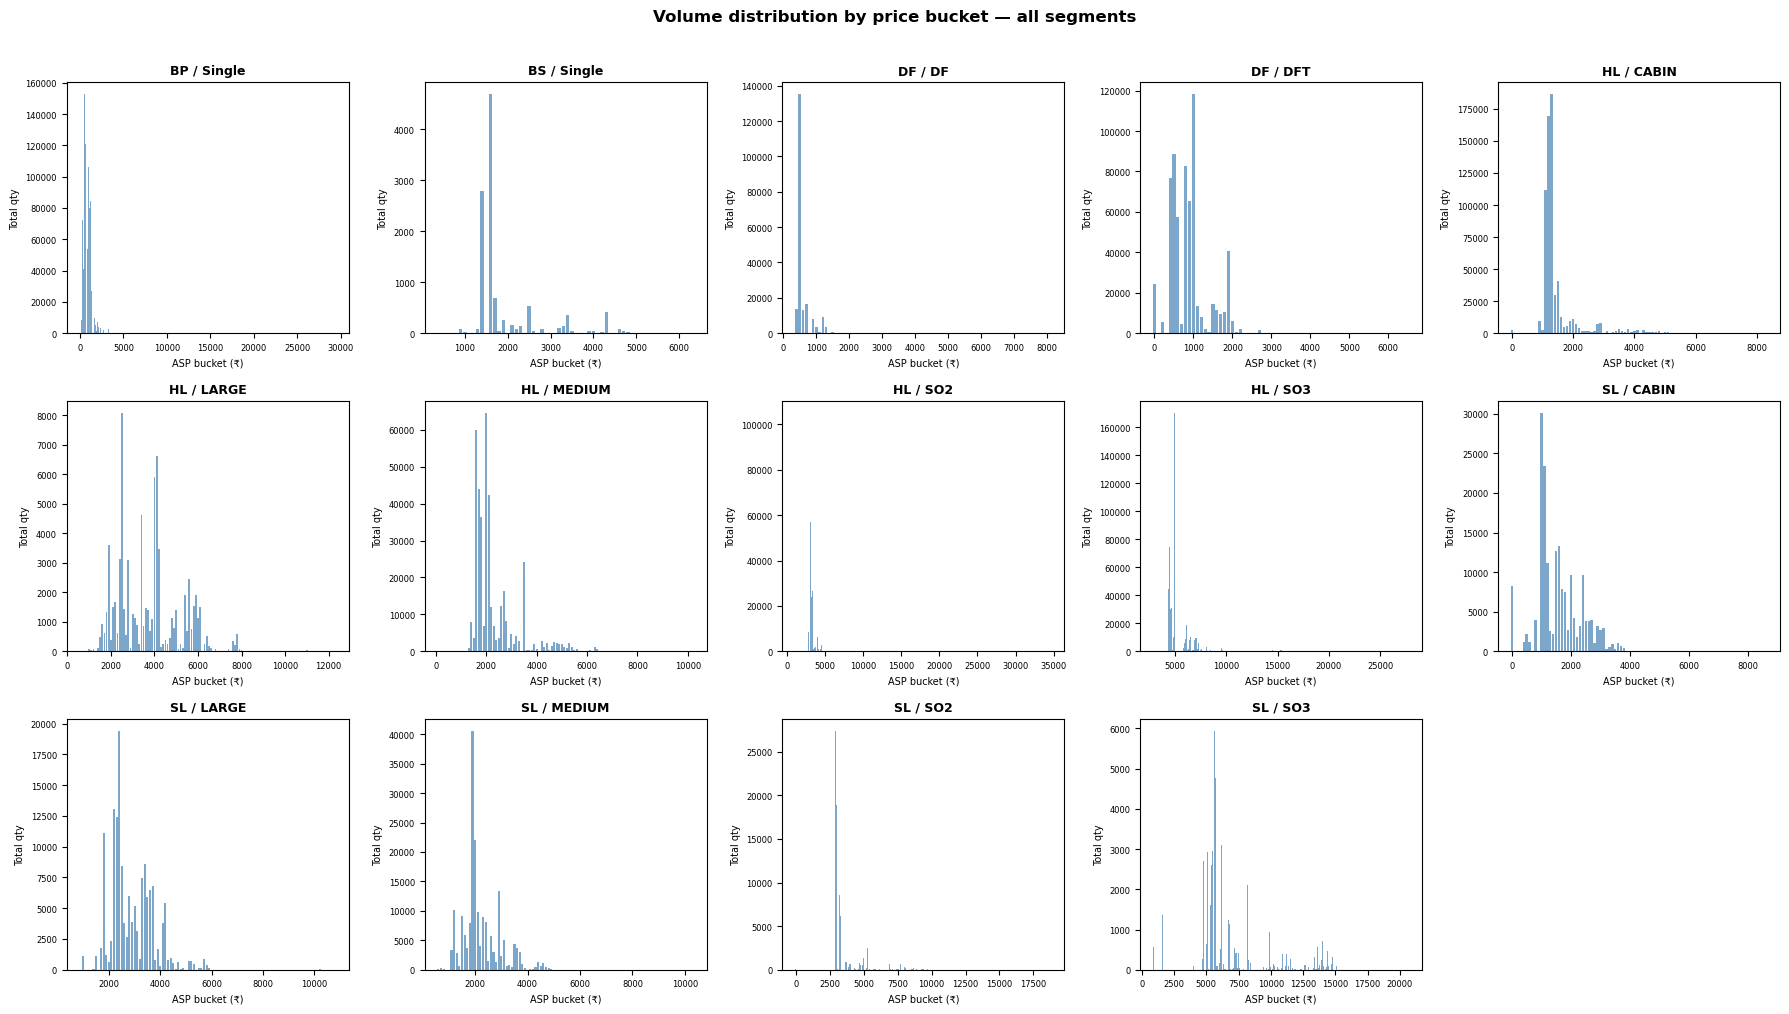

Saved: 02_price_distributions.png


In [7]:
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()

segments = sorted(bucket_ts.groupby(['Division', 'Size']).groups.keys())

for idx, (div, size) in enumerate(segments):
    seg = bucket_ts[(bucket_ts['Division'] == div) & 
                    (bucket_ts['Size'] == size)]
    
    vol_by_bucket = seg.groupby('bucket_min')['qty'].sum()
    
    axes[idx].bar(vol_by_bucket.index, vol_by_bucket.values, 
                  width=80, color='steelblue', alpha=0.7)
    axes[idx].set_title(f'{div} / {size}', fontsize=9, fontweight='bold')
    axes[idx].set_xlabel('ASP bucket (₹)', fontsize=7)
    axes[idx].set_ylabel('Total qty', fontsize=7)
    axes[idx].tick_params(labelsize=6)

# Hide the last empty subplot if segments < 15
for idx in range(len(segments), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Volume distribution by price bucket — all segments', 
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
os.makedirs(OUT_PATH, exist_ok=True)
plt.savefig(f'{OUT_PATH}02_price_distributions.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 02_price_distributions.png")

In [8]:
bucket_ts.to_csv(f'{OUT_PATH}02_fine_bucket_ts.csv', index=False)

print("NOTEBOOK 02 COMPLETE")
print(f"Saved: 02_fine_bucket_ts.csv")
print(f"\nSummary:")
print(f"  Input rows          : 43,905")
print(f"  Grouped range-months: {len(grp):,}")
print(f"  Fine bucket rows    : {len(bucket_ts):,}")
print(f"  Segments ready      : 14")
print(f"\nNext: 03_trend_pivot.ipynb")

NOTEBOOK 02 COMPLETE
Saved: 02_fine_bucket_ts.csv

Summary:
  Input rows          : 43,905
  Grouped range-months: 12,810
  Fine bucket rows    : 6,325
  Segments ready      : 14

Next: 03_trend_pivot.ipynb
